# Practice 17 — 고급 CNN (Advanced CNN)

Lec 09 강의 내용을 기반으로 **모던 CNN의 핵심 기법**을 비교 실험으로 학습합니다.

P16의 2-layer CNN을 출발점으로, 한 번에 한 가지씩 추가하며 효과를 격리합니다.

| # | 비교 (A vs B) | 격리 효과 |
|---|---|---|
| 2-1 | 얕은 (P16) vs 깊은 | 깊이 |
| 2-2 | 깊은 vs 깊은 + BatchNorm | BN |
| 2-3 | 깊은+BN vs 깊은+BN+Dropout | Dropout |
| 3 | 증강 없음 vs 데이터 증강 | Augmentation |
| 4 | **ImageFolder + Pretrained ResNet18** — 실전 데이터 파이프라인 | Transfer Learning |
| 5 | (시각화) 학습된 conv 필터 + feature map | Interpretability |

데이터: **Fashion-MNIST** (메인) + **CIFAR-10 일부** (전이학습, ImageFolder 형식으로 변환)


In [1]:
# Windows + conda 환경에서 torch와 torchvision 동시 로드 시 OpenMP 충돌 회피
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'

import numpy as np
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Subset
import matplotlib.pyplot as plt

torch.manual_seed(42)
np.random.seed(42)

print('torch:', torch.__version__)
print('torchvision:', torchvision.__version__)


torch: 2.6.0+cu124
torchvision: 0.21.0+cu124


---
# 1. Conv-BN-ReLU 블록

P12에서 본 BatchNorm을 **2D 텐서 (이미지)** 에 맞게 확장한 것이 `BatchNorm2d` 입니다. 채널별로 정규화합니다.

$$\hat{x}_{n,c,h,w} = \frac{x_{n,c,h,w} - \mu_c}{\sqrt{\sigma_c^2 + \epsilon}}, \qquad y_{n,c,h,w} = \gamma_c\,\hat{x}_{n,c,h,w} + \beta_c$$

모던 CNN의 표준 빌딩 블록은 다음 패턴입니다:

```
Conv2d → BatchNorm2d → ReLU
```

이번 노트북에서는 이 패턴을 도입하면 학습이 어떻게 달라지는지 비교 실험으로 살펴봅니다.


---
# 2. Fashion-MNIST 데이터 파이프라인

Fashion-MNIST는 MNIST와 같은 28x28 흑백 이미지(10클래스)지만, **옷·신발 사진**으로 구성되어 더 어렵습니다.


Train: 3000 samples
Test : 2000 samples


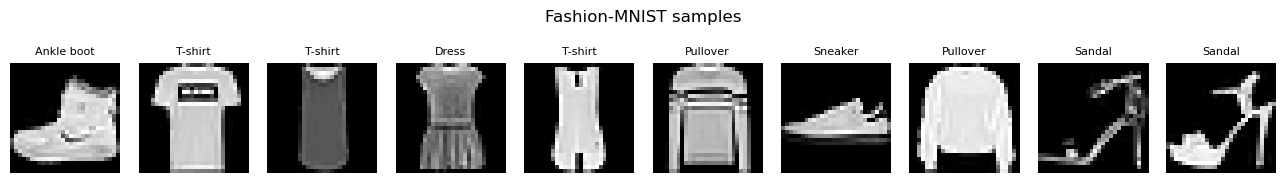

In [2]:
# Fashion-MNIST 로드 — 의도적으로 train 작게 (3000)
# P13처럼 과적합/규제 효과를 분명히 보기 위해 train 일부만 사용합니다.
transform = transforms.ToTensor()

train_full = torchvision.datasets.FashionMNIST(
    root='./data', train=True, download=True, transform=transform)
test_full = torchvision.datasets.FashionMNIST(
    root='./data', train=False, download=True, transform=transform)

train_set = Subset(train_full, indices=list(range(3000)))
test_set  = Subset(test_full,  indices=list(range(2000)))

train_loader = DataLoader(train_set, batch_size=128, shuffle=True)
test_loader  = DataLoader(test_set,  batch_size=256, shuffle=False)

class_names = ['T-shirt', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal',  'Shirt',   'Sneaker',  'Bag',   'Ankle boot']

print(f'Train: {len(train_set)} samples')
print(f'Test : {len(test_set)} samples')

# 샘플 10장 시각화
fig, axes = plt.subplots(1, 10, figsize=(13, 1.7))
for i in range(10):
    img_i, label_i = train_set[i]
    axes[i].imshow(img_i.squeeze(), cmap='gray')
    axes[i].set_title(class_names[label_i], fontsize=8)
    axes[i].axis('off')
plt.suptitle('Fashion-MNIST samples', y=1.05)
plt.tight_layout(); plt.show()


In [3]:
# 모델 학습 함수 (P16과 동일)
def train(model, train_loader, test_loader, optimizer, epochs=12):
    criterion = nn.CrossEntropyLoss()
    train_losses, test_losses, test_accs = [], [], []
    for epoch in range(epochs):
        model.train()
        loss_sum, count = 0.0, 0
        for X_batch, Y_batch in train_loader:
            output = model(X_batch)
            loss = criterion(output, Y_batch)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            loss_sum += loss.item() * len(Y_batch)
            count += len(Y_batch)
        train_losses.append(loss_sum / count)

        model.eval()
        loss_sum, correct, count = 0.0, 0, 0
        with torch.no_grad():
            for X_batch, Y_batch in test_loader:
                output = model(X_batch)
                loss_sum += criterion(output, Y_batch).item() * len(Y_batch)
                correct += (output.argmax(1) == Y_batch).sum().item()
                count += len(Y_batch)
        test_losses.append(loss_sum / count)
        test_accs.append(correct / count)
        print(f'  Epoch {epoch+1}/{epochs}  '
              f'train_loss={train_losses[-1]:.4f}  '
              f'test_loss={test_losses[-1]:.4f}  '
              f'test_acc={test_accs[-1]:.4f}')
    return train_losses, test_losses, test_accs


# 비교 그래프 헬퍼
def plot_compare(r_a, r_b, label_a, label_b, title_prefix):
    _, _, va_a = r_a
    _, _, va_b = r_b
    _, vl_a, _ = r_a
    _, vl_b, _ = r_b
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(vl_a, 'o-', label=label_a)
    axes[0].plot(vl_b, 's-', label=label_b)
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Test Loss')
    axes[0].set_title(f'{title_prefix} - Test Loss')
    axes[0].legend(); axes[0].grid(alpha=0.3)
    axes[1].plot(va_a, 'o-', label=label_a)
    axes[1].plot(va_b, 's-', label=label_b)
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Test Accuracy')
    axes[1].set_title(f'{title_prefix} - Test Accuracy')
    axes[1].legend(); axes[1].grid(alpha=0.3)
    plt.tight_layout(); plt.show()


---
# 2-1. 깊이 효과: 얕은 (P16) vs 깊은

가장 단순한 비교: 같은 컴포넌트로 **레이어 개수만** 바꾼다.

- **얕은 모델** (Shallow): Conv 2개 (P16과 동일 구조)
- **깊은 모델** (Deep): Conv 4개

BN/Dropout은 **둘 다 없음**. 깊이 효과만 격리.


In [4]:
# 얕은 CNN — P16과 동일한 2-layer
class CNN_Shallow(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer1 = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2))                  # 28 -> 14
        self.layer2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2))                  # 14 -> 7
        self.fc = nn.Linear(64 * 7 * 7, 10)

    def forward(self, x):
        x = self.layer1(x)
        x = self.layer2(x)
        x = x.flatten(1)
        x = self.fc(x)
        return x


# 깊은 CNN — Conv 4개, BN/Dropout 없음
class CNN_Deep(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer1 = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2))                  # 28 -> 14
        self.layer2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2))                  # 14 -> 7
        self.layer3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2))                  # 7 -> 3
        self.layer4 = nn.Sequential(
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.ReLU())                        # 3 -> 3 (pool 없음)
        self.fc = nn.Linear(128 * 3 * 3, 10)

    def forward(self, x):
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = x.flatten(1)
        x = self.fc(x)
        return x


print(f'Shallow params: {sum(p.numel() for p in CNN_Shallow().parameters()):,}')
print(f'Deep    params: {sum(p.numel() for p in CNN_Deep().parameters()):,}')


Shallow params: 50,186
Deep    params: 251,786


Training Shallow...


  Epoch 1/12  train_loss=1.6200  test_loss=0.9042  test_acc=0.6625


  Epoch 2/12  train_loss=0.8093  test_loss=0.7403  test_acc=0.7115


  Epoch 3/12  train_loss=0.6678  test_loss=0.6433  test_acc=0.7480


  Epoch 4/12  train_loss=0.5823  test_loss=0.5463  test_acc=0.7965


...

  Epoch 8/12  train_loss=0.4915  test_loss=0.5314  test_acc=0.8080


  Epoch 9/12  train_loss=0.4569  test_loss=0.5559  test_acc=0.8000


  Epoch 10/12  train_loss=0.4630  test_loss=0.5599  test_acc=0.7845


  Epoch 11/12  train_loss=0.4108  test_loss=0.4653  test_acc=0.8345


  Epoch 12/12  train_loss=0.3806  test_loss=0.4528  test_acc=0.8365


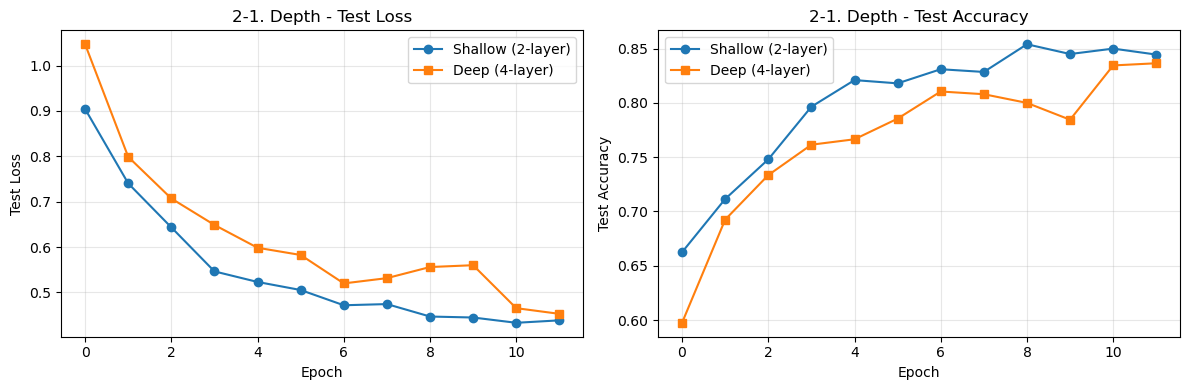

Shallow final acc: 0.8445
Deep    final acc: 0.8365


In [5]:
# === 얕은 모델 학습 ===
torch.manual_seed(42)
model_shallow = CNN_Shallow()
opt_shallow = torch.optim.Adam(model_shallow.parameters(), lr=1e-3)
print('Training Shallow...')
r_shallow = train(model_shallow, train_loader, test_loader, opt_shallow, epochs=12)

# === 깊은 모델 학습 ===
torch.manual_seed(42)
model_deep = CNN_Deep()
opt_deep = torch.optim.Adam(model_deep.parameters(), lr=1e-3)
print('\nTraining Deep (no BN, no Drop)...')
r_deep = train(model_deep, train_loader, test_loader, opt_deep, epochs=12)

# 비교
plot_compare(r_shallow, r_deep, 'Shallow (2-layer)', 'Deep (4-layer)', '2-1. Depth')
print(f'Shallow final acc: {r_shallow[2][-1]:.4f}')
print(f'Deep    final acc: {r_deep[2][-1]:.4f}')


---
# 2-2. BatchNorm2d 효과: 깊은 vs 깊은 + BN

같은 깊은 구조에 **Conv-BN-ReLU 블록**을 적용한다.

- **A**: 깊은 모델 (no BN) — 위 2-1의 `r_deep` 재사용
- **B**: 깊은 + BatchNorm2d

BN을 도입하면 학습이 더 안정적이고 빠르게 수렴합니다.


In [6]:
# 깊은 + BN
class CNN_Deep_BN(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer1 = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),                  # <- 추가
            nn.ReLU(),
            nn.MaxPool2d(2))
        self.layer2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2))
        self.layer3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2))
        self.layer4 = nn.Sequential(
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU())
        self.fc = nn.Linear(128 * 3 * 3, 10)

    def forward(self, x):
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = x.flatten(1)
        x = self.fc(x)
        return x

print(f'Deep+BN params: {sum(p.numel() for p in CNN_Deep_BN().parameters()):,}')


Deep+BN params: 252,490


Training Deep + BN...


  Epoch 1/12  train_loss=0.9243  test_loss=1.3747  test_acc=0.5805


  Epoch 2/12  train_loss=0.4676  test_loss=0.5407  test_acc=0.8150


  Epoch 3/12  train_loss=0.3901  test_loss=0.4794  test_acc=0.8300


  Epoch 4/12  train_loss=0.2756  test_loss=0.4417  test_acc=0.8350


...

  Epoch 8/12  train_loss=0.0914  test_loss=0.4525  test_acc=0.8590


  Epoch 9/12  train_loss=0.0424  test_loss=0.3957  test_acc=0.8760


  Epoch 10/12  train_loss=0.0246  test_loss=0.4047  test_acc=0.8720


  Epoch 11/12  train_loss=0.0112  test_loss=0.4638  test_acc=0.8620


  Epoch 12/12  train_loss=0.0078  test_loss=0.4151  test_acc=0.8725


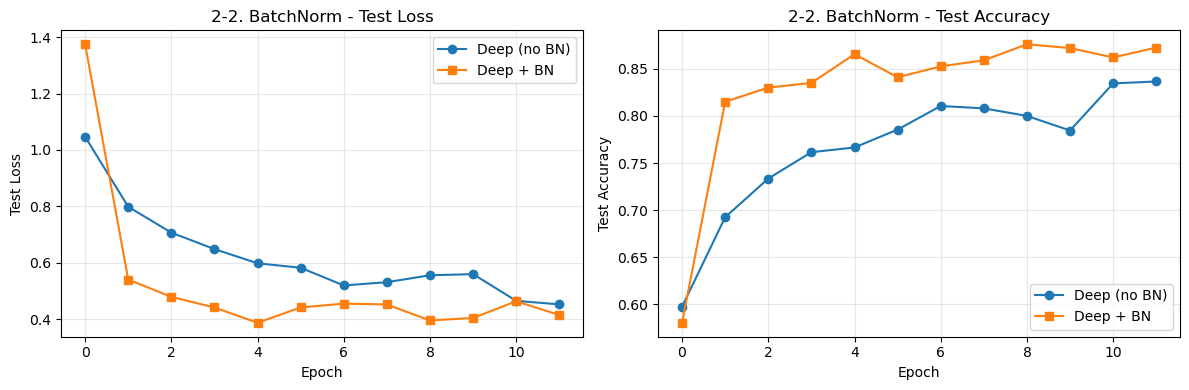

Deep      final acc: 0.8365
Deep + BN final acc: 0.8725


In [7]:
# === 깊은 + BN 학습 ===
torch.manual_seed(42)
model_deep_bn = CNN_Deep_BN()
opt_deep_bn = torch.optim.Adam(model_deep_bn.parameters(), lr=1e-3)
print('Training Deep + BN...')
r_deep_bn = train(model_deep_bn, train_loader, test_loader, opt_deep_bn, epochs=12)

# 비교 (A=r_deep 재사용)
plot_compare(r_deep, r_deep_bn, 'Deep (no BN)', 'Deep + BN', '2-2. BatchNorm')
print(f'Deep      final acc: {r_deep[2][-1]:.4f}')
print(f'Deep + BN final acc: {r_deep_bn[2][-1]:.4f}')


---
# 2-3. Dropout 효과: 깊은+BN vs 깊은+BN+Dropout

P13에서 본 Dropout을 CNN에 적용. 보통 **FC 직전** 또는 **conv 블록 사이**에 넣습니다.

- **A**: 깊은+BN (Dropout 없음) — 위 2-2의 `r_deep_bn` 재사용
- **B**: 깊은+BN + Dropout (FC 직전 0.5)


In [8]:
# 깊은 + BN + Dropout
class CNN_Deep_BN_Drop(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer1 = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2))
        self.layer2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2))
        self.layer3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2))
        self.layer4 = nn.Sequential(
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU())
        self.dropout = nn.Dropout(0.5)           # <- 추가
        self.fc = nn.Linear(128 * 3 * 3, 10)

    def forward(self, x):
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = x.flatten(1)
        x = self.dropout(x)
        x = self.fc(x)
        return x

print(f'Deep+BN+Drop params: {sum(p.numel() for p in CNN_Deep_BN_Drop().parameters()):,}')


Deep+BN+Drop params: 252,490


Training Deep + BN + Dropout...


  Epoch 1/12  train_loss=0.9847  test_loss=1.3936  test_acc=0.5870


  Epoch 2/12  train_loss=0.5273  test_loss=0.5934  test_acc=0.7895


  Epoch 3/12  train_loss=0.3991  test_loss=0.4287  test_acc=0.8405


  Epoch 4/12  train_loss=0.3342  test_loss=0.4237  test_acc=0.8530


...

  Epoch 8/12  train_loss=0.1431  test_loss=0.3790  test_acc=0.8665


  Epoch 9/12  train_loss=0.1239  test_loss=0.3910  test_acc=0.8650


  Epoch 10/12  train_loss=0.0827  test_loss=0.3943  test_acc=0.8715


  Epoch 11/12  train_loss=0.0748  test_loss=0.4075  test_acc=0.8620


  Epoch 12/12  train_loss=0.0499  test_loss=0.4362  test_acc=0.8610


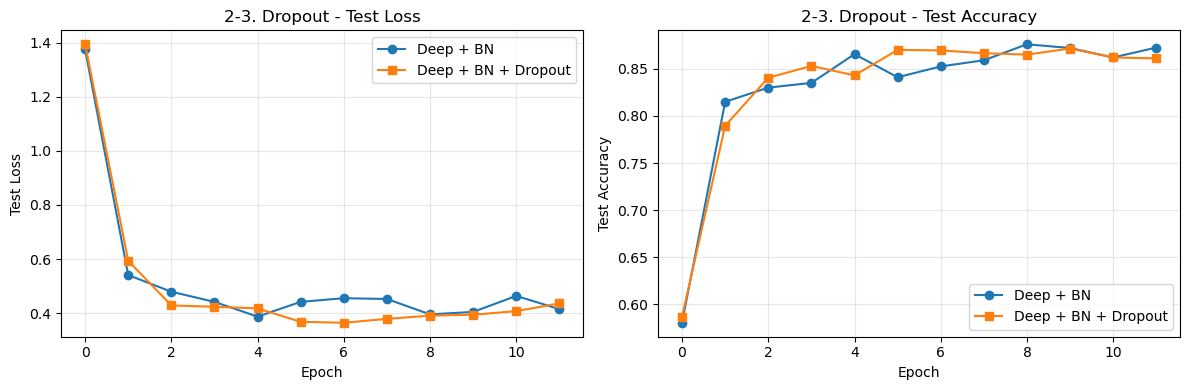

Deep + BN        final acc: 0.8725
Deep + BN + Drop final acc: 0.8610


In [9]:
# === 깊은 + BN + Dropout 학습 ===
torch.manual_seed(42)
model_deep_bn_drop = CNN_Deep_BN_Drop()
opt_deep_bn_drop = torch.optim.Adam(model_deep_bn_drop.parameters(), lr=1e-3)
print('Training Deep + BN + Dropout...')
r_deep_bn_drop = train(model_deep_bn_drop, train_loader, test_loader, opt_deep_bn_drop, epochs=12)

# 비교 (A=r_deep_bn 재사용)
plot_compare(r_deep_bn, r_deep_bn_drop, 'Deep + BN', 'Deep + BN + Dropout', '2-3. Dropout')
print(f'Deep + BN        final acc: {r_deep_bn[2][-1]:.4f}')
print(f'Deep + BN + Drop final acc: {r_deep_bn_drop[2][-1]:.4f}')


---
# 3. 데이터 증강 (Data Augmentation)

학습 시 매 epoch마다 입력에 **랜덤 변환**을 적용 → 사실상 데이터 양이 늘어나는 효과.

**전형적인 증강:** RandomCrop, RandomHorizontalFlip, RandomRotation, ColorJitter ...

- **A**: 깊은+BN+Drop, **증강 없음** — 위 2-3의 `r_deep_bn_drop` 재사용
- **B**: 깊은+BN+Drop, **증강 적용**

> 주의: 증강은 **train set에만** 적용합니다. test set에는 절대 안 됨.
>
> 또한 증강 모델은 매 epoch마다 다른 입력을 보므로 **수렴이 더 느립니다**. epoch을 충분히 늘려야 진가가 드러납니다.


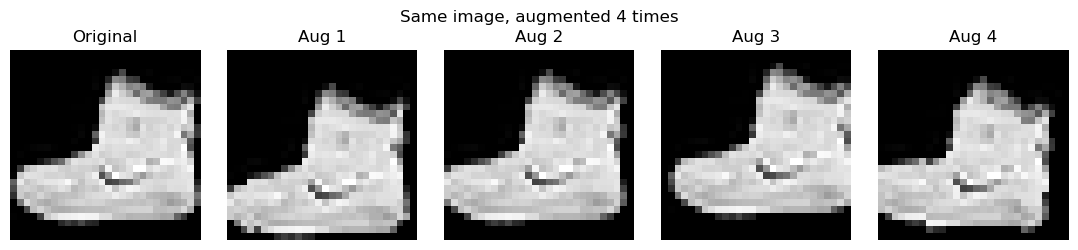

In [10]:
# 증강된 train transform — RandomCrop + RandomRotation
# (Fashion-MNIST에 좌우반전은 일부 클래스 혼란 유발 가능 → 사용 안 함)
transform_aug = transforms.Compose([
    transforms.RandomCrop(28, padding=2),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
])

# Fashion-MNIST를 같은 부분집합으로 다시 로드 (transform만 다름)
train_full_aug = torchvision.datasets.FashionMNIST(
    root='./data', train=True, download=True, transform=transform_aug)
train_set_aug = Subset(train_full_aug, indices=list(range(3000)))
train_loader_aug = DataLoader(train_set_aug, batch_size=128, shuffle=True)

# 같은 이미지를 4번 변환해서 시각화 (랜덤성 확인)
torch.manual_seed(0)
img0, _ = train_set_aug[0]
fig, axes = plt.subplots(1, 5, figsize=(11, 2.5))
img_orig, _ = train_set[0]                     # 원본
axes[0].imshow(img_orig.squeeze(), cmap='gray')
axes[0].set_title('Original'); axes[0].axis('off')
for i in range(4):
    img_i, _ = train_set_aug[0]                # 매번 다른 변환
    axes[i+1].imshow(img_i.squeeze(), cmap='gray')
    axes[i+1].set_title(f'Aug {i+1}'); axes[i+1].axis('off')
plt.suptitle('Same image, augmented 4 times')
plt.tight_layout(); plt.show()


Training Deep + BN + Drop + Augmentation...


  Epoch 1/12  train_loss=1.1827  test_loss=1.6163  test_acc=0.4460


  Epoch 2/12  train_loss=0.7056  test_loss=0.6216  test_acc=0.7525


  Epoch 3/12  train_loss=0.6305  test_loss=0.5163  test_acc=0.7945


  Epoch 4/12  train_loss=0.5642  test_loss=0.5197  test_acc=0.7925


...

  Epoch 8/12  train_loss=0.4555  test_loss=0.4378  test_acc=0.8350


  Epoch 9/12  train_loss=0.4204  test_loss=0.4005  test_acc=0.8475


  Epoch 10/12  train_loss=0.4295  test_loss=0.4146  test_acc=0.8500


  Epoch 11/12  train_loss=0.4185  test_loss=0.3935  test_acc=0.8550


  Epoch 12/12  train_loss=0.3859  test_loss=0.4233  test_acc=0.8555


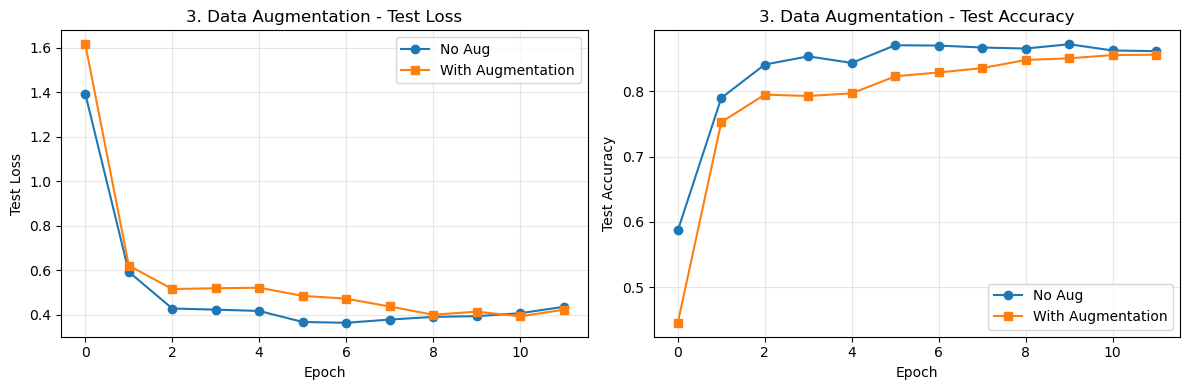

No Aug          final acc: 0.8610
With Aug        final acc: 0.8555


In [11]:
# === 깊은 + BN + Drop + 증강 학습 ===
torch.manual_seed(42)
model_deep_aug = CNN_Deep_BN_Drop()
opt_deep_aug = torch.optim.Adam(model_deep_aug.parameters(), lr=1e-3)
print('Training Deep + BN + Drop + Augmentation...')
r_deep_aug = train(model_deep_aug, train_loader_aug, test_loader, opt_deep_aug, epochs=12)

# 비교 (A=r_deep_bn_drop 재사용)
plot_compare(r_deep_bn_drop, r_deep_aug,
             'No Aug', 'With Augmentation', '3. Data Augmentation')
print(f'No Aug          final acc: {r_deep_bn_drop[2][-1]:.4f}')
print(f'With Aug        final acc: {r_deep_aug[2][-1]:.4f}')


---
# 4. 실전 데이터 파이프라인: ImageFolder + 전이학습

지금까지는 `torchvision.datasets` 가 제공하는 표준 데이터셋(MNIST, Fashion-MNIST)만 사용했습니다.

실전에서는 **여러분이 직접 모은 사진**으로 학습합니다. PyTorch의 `datasets.ImageFolder` 는
**클래스별 하위 폴더에 이미지를 저장**해두면 자동으로 라벨을 붙여 데이터셋을 만들어줍니다.

```
data_root/
├── plane/
│   ├── img_000.png
│   ├── img_001.png
│   └── ...
├── car/
│   └── ...
└── bird/
    └── ...
```

**여기서는 CIFAR-10에서 5개 클래스 일부를 꺼내 위 구조로 저장하고**, ImageFolder로 다시 로드해 사전학습 ResNet18로 분류합니다.

이 패턴은 **여러분 자신의 사진 폴더에 그대로 적용 가능**합니다.


## 4-1. CIFAR-10 → ImageFolder 구조 생성

`torchvision.datasets.CIFAR10` 을 transform 없이 로드하면 PIL Image로 받습니다. 이를 폴더에 PNG로 저장합니다.


In [12]:
import shutil
from PIL import Image

ROOT = './data/cifar5_imagefolder'
classes = ['plane', 'car', 'bird', 'cat', 'deer']   # CIFAR-10 첫 5클래스
N_TRAIN_PER_CLASS = 40
N_TEST_PER_CLASS  = 10

# 기존 폴더 정리 후 새로 생성
if os.path.exists(ROOT):
    shutil.rmtree(ROOT)
for split in ['train', 'test']:
    for c in classes:
        os.makedirs(f'{ROOT}/{split}/{c}', exist_ok=True)

# CIFAR-10 로드 (transform 없이 → PIL Image 그대로)
cifar_train_pil = torchvision.datasets.CIFAR10(root='./data', train=True,  download=True)
cifar_test_pil  = torchvision.datasets.CIFAR10(root='./data', train=False, download=True)

# train: 클래스당 N_TRAIN_PER_CLASS 장 저장
counts = [0] * 5
for img, label in cifar_train_pil:
    if label < 5 and counts[label] < N_TRAIN_PER_CLASS:
        img.save(f'{ROOT}/train/{classes[label]}/img_{counts[label]:03d}.png')
        counts[label] += 1
    if all(c >= N_TRAIN_PER_CLASS for c in counts):
        break

# test: 클래스당 N_TEST_PER_CLASS 장
counts = [0] * 5
for img, label in cifar_test_pil:
    if label < 5 and counts[label] < N_TEST_PER_CLASS:
        img.save(f'{ROOT}/test/{classes[label]}/img_{counts[label]:03d}.png')
        counts[label] += 1
    if all(c >= N_TEST_PER_CLASS for c in counts):
        break

# 만들어진 폴더 구조 확인
print(f'Created folder structure under {ROOT}/')
for split in ['train', 'test']:
    print(f'\n  {split}/')
    for c in sorted(os.listdir(f'{ROOT}/{split}')):
        n = len(os.listdir(f'{ROOT}/{split}/{c}'))
        print(f'    {c}/  ({n} images)')


Created folder structure under ./data/cifar5_imagefolder/

  train/
    bird/  (40 images)
    car/  (40 images)
    cat/  (40 images)
    deer/  (40 images)
    plane/  (40 images)

  test/
    bird/  (10 images)
    car/  (10 images)
    cat/  (10 images)
    deer/  (10 images)
    plane/  (10 images)


## 4-2. ImageFolder 로 로드

이제 만들어진 폴더 구조를 `torchvision.datasets.ImageFolder` 로 한 줄에 데이터셋으로 만들 수 있습니다.

- 폴더 이름이 **클래스명**이 됨 (알파벳 순으로 인덱스 자동 부여)
- 이미지는 PIL Image로 읽힌 후 transform 적용
- ResNet18은 224x224 RGB 입력을 가정하므로 Resize + Normalize (ImageNet 표준)


Train: 200 samples
Test : 50 samples
Classes      : ['bird', 'car', 'cat', 'deer', 'plane']
Class -> idx : {'bird': 0, 'car': 1, 'cat': 2, 'deer': 3, 'plane': 4}


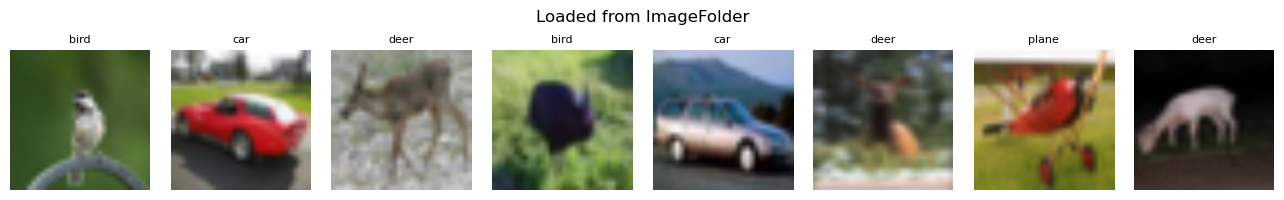

In [13]:
# ImageNet 표준 전처리 (pretrained 모델용)
transform_imgnet = transforms.Compose([
    transforms.Resize(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

train_imgfolder = torchvision.datasets.ImageFolder(
    root=f'{ROOT}/train', transform=transform_imgnet)
test_imgfolder = torchvision.datasets.ImageFolder(
    root=f'{ROOT}/test',  transform=transform_imgnet)

print(f'Train: {len(train_imgfolder)} samples')
print(f'Test : {len(test_imgfolder)} samples')
print(f'Classes      : {train_imgfolder.classes}')
print(f'Class -> idx : {train_imgfolder.class_to_idx}')

cifar_train_loader = DataLoader(train_imgfolder, batch_size=32, shuffle=True)
cifar_test_loader  = DataLoader(test_imgfolder,  batch_size=32, shuffle=False)

# 한 배치 시각화 (정규화 되돌려서 표시)
X_batch, y_batch = next(iter(cifar_train_loader))
mean = np.array([0.485, 0.456, 0.406])
std  = np.array([0.229, 0.224, 0.225])

fig, axes = plt.subplots(1, 8, figsize=(13, 2))
for i in range(8):
    img_show = X_batch[i].permute(1, 2, 0).numpy() * std + mean   # un-normalize
    img_show = np.clip(img_show, 0, 1)
    axes[i].imshow(img_show)
    axes[i].set_title(train_imgfolder.classes[y_batch[i]], fontsize=8)
    axes[i].axis('off')
plt.suptitle('Loaded from ImageFolder')
plt.tight_layout(); plt.show()


## 4-3. Pretrained ResNet18 으로 fine-tuning

큰 데이터셋(ImageNet, 120만 장)에서 사전 학습된 모델을 가져와 **마지막 FC 레이어만** 새로 학습합니다.

**전략 (Feature Extraction):**
1. backbone 동결 (`requires_grad=False`)
2. 마지막 FC 를 우리 클래스 수(5)로 교체
3. FC 만 학습 → 적은 데이터에 적합, 학습 매우 빠름


In [14]:
from torchvision.models import resnet18, ResNet18_Weights

# 가중치 다운로드 (첫 실행 시 약 45MB)
resnet = resnet18(weights=ResNet18_Weights.DEFAULT)

# 1단계: backbone 동결
for p in resnet.parameters():
    p.requires_grad = False

# 2단계: 마지막 FC를 5-class 분류기로 교체 (이 부분만 학습됨)
resnet.fc = nn.Linear(resnet.fc.in_features, 5)

n_total = sum(p.numel() for p in resnet.parameters())
n_train = sum(p.numel() for p in resnet.parameters() if p.requires_grad)
print(f'Total params:     {n_total:,}')
print(f'Trainable params: {n_train:,}  ({100*n_train/n_total:.2f}%)')


Total params:     11,179,077
Trainable params: 2,565  (0.02%)


In [15]:
# === 전이학습 학습 (마지막 FC만 업데이트) ===
torch.manual_seed(42)
opt_resnet = torch.optim.Adam(
    [p for p in resnet.parameters() if p.requires_grad], lr=1e-3)

print('Fine-tuning pretrained ResNet18 (FC only)...')
r_resnet = train(resnet, cifar_train_loader, cifar_test_loader,
                 opt_resnet, epochs=3)
print(f'\nFinal test accuracy: {r_resnet[2][-1]:.4f}')
print('-> 200장(train) 만으로도 의미 있게 수렴 (사전학습된 feature 덕분).')
print('-> 핵심 메시지: 여러분의 사진을 폴더로 정리하면 같은 코드로 학습 가능.')


Fine-tuning pretrained ResNet18 (FC only)...


  Epoch 1/3  train_loss=1.7398  test_loss=1.6400  test_acc=0.3200


  Epoch 2/3  train_loss=1.4760  test_loss=1.3789  test_acc=0.4600


  Epoch 3/3  train_loss=1.2562  test_loss=1.2508  test_acc=0.5400

Final test accuracy: 0.5400
-> 200장(train) 만으로도 의미 있게 수렴 (사전학습된 feature 덕분).
-> 핵심 메시지: 여러분의 사진을 폴더로 정리하면 같은 코드로 학습 가능.


---
# 5. CNN 시각화 — 학습된 필터와 feature map

CNN이 무엇을 "보고" 있는지 두 가지 방법으로 시각화합니다.

1. **첫 conv 레이어의 학습된 필터** — 작은 패턴 검출기
2. **Forward hook으로 feature map 추출** — 입력에 대한 채널별 활성


First conv weight shape: (32, 1, 3, 3)


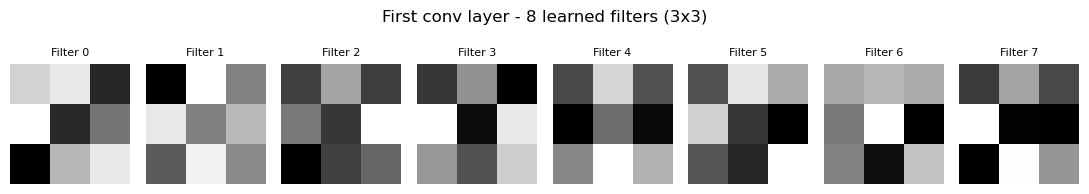

In [16]:
# 위에서 학습한 깊은+BN+Drop 모델의 첫 conv 필터 8개 시각화
first_conv = model_deep_bn_drop.layer1[0]   # nn.Conv2d(1, 32, ...)
filters = first_conv.weight.detach().cpu().numpy()   # (32, 1, 3, 3)
print(f'First conv weight shape: {filters.shape}')

fig, axes = plt.subplots(1, 8, figsize=(11, 1.8))
for i in range(8):
    f = filters[i, 0]                         # (3, 3)
    axes[i].imshow(f, cmap='gray')
    axes[i].set_title(f'Filter {i}', fontsize=8)
    axes[i].axis('off')
plt.suptitle('First conv layer - 8 learned filters (3x3)', y=1.05)
plt.tight_layout(); plt.show()


Feature map shape: (32, 14, 14)  (32 channels, 14x14)


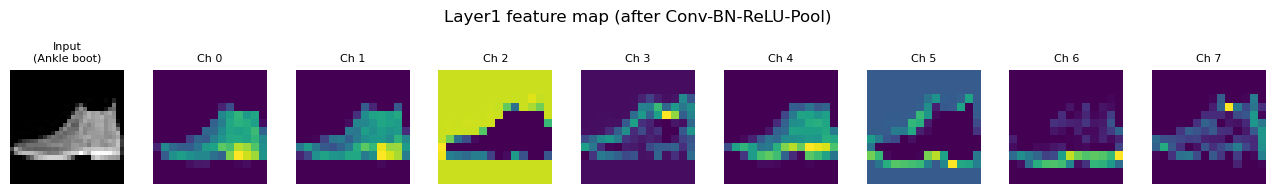

In [17]:
# Forward hook으로 1번째 layer의 출력(feature map) 추출
activations = []
def save_act(module, input, output):
    activations.append(output.detach().cpu())

handle = model_deep_bn_drop.layer1.register_forward_hook(save_act)

# Fashion-MNIST 샘플 하나를 forward
img_sample, label_sample = test_set[0]
model_deep_bn_drop.eval()
with torch.no_grad():
    _ = model_deep_bn_drop(img_sample.unsqueeze(0))   # (1, 1, 28, 28)

handle.remove()

feat = activations[0][0]                              # (32, 14, 14) - layer1 출력
print(f'Feature map shape: {tuple(feat.shape)}  (32 channels, 14x14)')

# 입력 + 8개 채널 시각화
fig, axes = plt.subplots(1, 9, figsize=(13, 1.8))
axes[0].imshow(img_sample.squeeze(), cmap='gray')
axes[0].set_title(f'Input\n({class_names[label_sample]})', fontsize=8)
axes[0].axis('off')
for i in range(8):
    axes[i+1].imshow(feat[i], cmap='viridis')
    axes[i+1].set_title(f'Ch {i}', fontsize=8)
    axes[i+1].axis('off')
plt.suptitle('Layer1 feature map (after Conv-BN-ReLU-Pool)', y=1.05)
plt.tight_layout(); plt.show()


---
# 6. 정리

| 기법 | 효과 | 본 노트북 결과 |
|------|------|--------------|
| **깊이 (Deep)** | 표현력 증가, 과적합 위험 (BN/Drop 필요) | 깊이만 늘리면 오히려 약간 하락 |
| **BatchNorm2d** | 학습 안정화, 더 빠른 수렴, 약한 규제 | **명확한 향상** |
| **Dropout** | 과적합 감소, 일반화 향상 | 효과 미미 (수렴 느려짐) |
| **Data Augmentation** | 사실상 데이터 증가, 일반화 향상 | 효과 미미 (epoch 더 필요) |
| **ImageFolder** | 임의의 폴더 구조 → DataLoader 한 줄 | 표준 데이터셋 외 사진을 다룰 수 있음 |
| **Transfer Learning** | 적은 데이터로도 빠른 수렴 (ImageNet 사전학습) | 200장만으로 의미 있는 정확도 |

> **왜 Dropout/Aug 효과가 작게 나왔나?**
>
> 두 기법 모두 **과적합이 심할 때** 진가를 발휘합니다. 본 노트북은 12 epoch 만에 끝나므로 과적합이 충분히 심해지기 전에 학습이 종료됩니다. epoch을 30~50으로 늘리거나 train 크기를 더 줄이면 두 기법의 효과가 분명히 나타납니다.

CNN을 실전에서 사용할 때는 위 기법들을 조합합니다 (모던 CNN의 표준 레시피).

---
### 연습 문제

1. `CNN_Deep_BN`과 `CNN_Deep_BN_Drop`의 학습 시간 차이를 측정해 보세요. (`time.time()` 활용)
2. `ResNet18` 외에 `resnet34`, `mobilenet_v2` 등으로 바꿔 정확도를 비교해 보세요.
3. 자신의 사진을 `data/my_photos/<클래스명>/<파일.jpg>` 형태로 저장하고, 4번 섹션 코드를 그대로 사용해 학습해 보세요.


In [18]:
# 연습 문제 풀이 공간
